In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine(
    "mysql+pymysql://root:@localhost:3309/ecommerce_analytics1"
)

print("Database Connected Successfully!")

query = """
SELECT COUNT(*) AS total_products
FROM products;
"""

total_products = pd.read_sql(query, engine)

total_products

Database Connected Successfully!


,total_products
0,32951


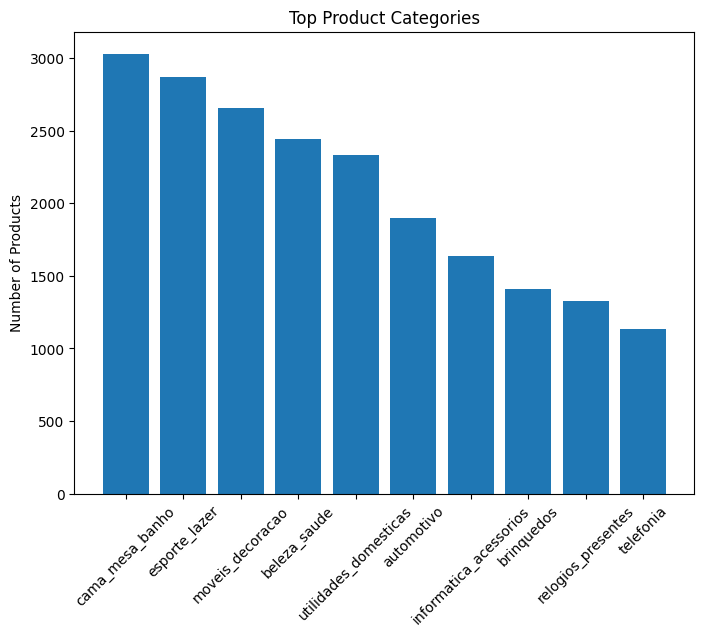

,product_category_name,total_sales
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641
3,moveis_decoracao,8334
4,informatica_acessorios,7827
5,utilidades_domesticas,6964
6,relogios_presentes,5991
7,telefonia,4545
8,ferramentas_jardim,4347
9,automotivo,4235


In [3]:
#  Top Product Categories
query = """
SELECT
    product_category_name,
    COUNT(*) AS total_products
FROM products
GROUP BY product_category_name
ORDER BY total_products DESC
LIMIT 10;
"""

top_categories = pd.read_sql(query, engine)

top_categories

#  Visualization
plt.figure(figsize=(8,6))

plt.bar(
    top_categories['product_category_name'],
    top_categories['total_products']
)

plt.xticks(rotation=45)

plt.title("Top Product Categories")
plt.ylabel("Number of Products")

plt.show()

# Most Sold Categories
query = """
SELECT
    p.product_category_name,
    COUNT(*) AS total_sales
FROM order_items oi
JOIN products p
ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY total_sales DESC
LIMIT 10;
"""

best_categories = pd.read_sql(query, engine)

best_categories

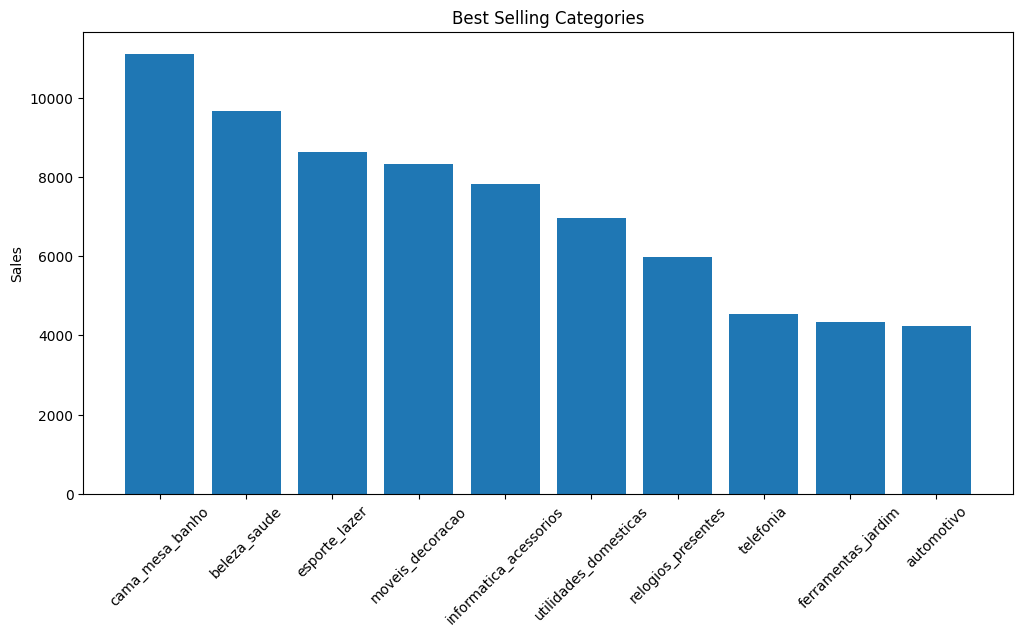

In [4]:
plt.figure(figsize=(12,6))

plt.bar(
    best_categories['product_category_name'],
    best_categories['total_sales']
)

plt.xticks(rotation=45)

plt.title("Best Selling Categories")
plt.ylabel("Sales")

plt.show()

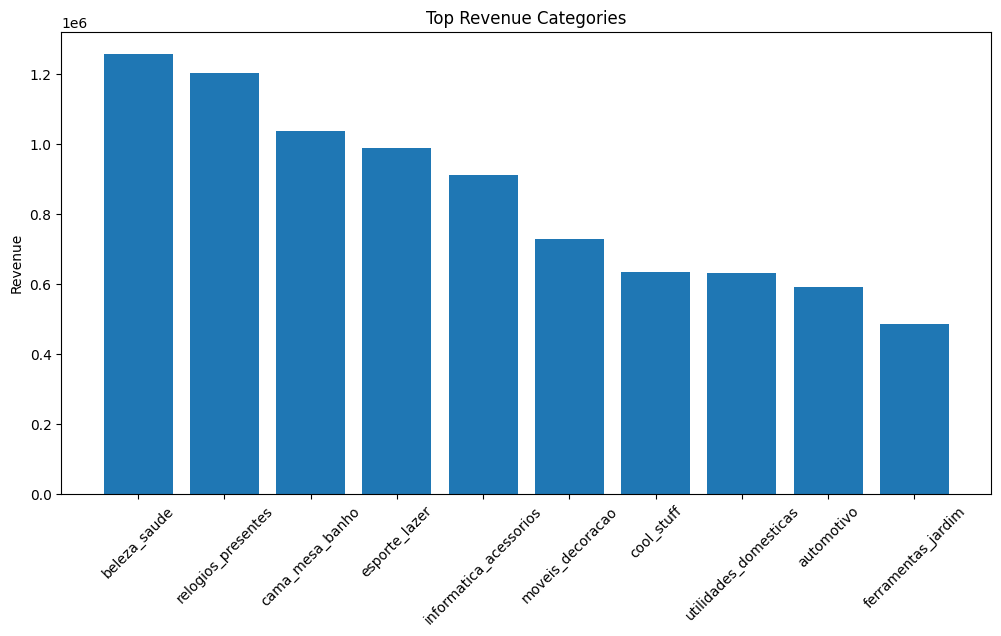

,product_id,highest_price
0,489ae2aa008f021502940f251d4cce7f,6735.0
1,69c590f7ffc7bf8db97190b6cb6ed62e,6729.0
2,1bdf5e6731585cf01aa8169c7028d6ad,6499.0
3,a6492cc69376c469ab6f61d8f44de961,4799.0
4,c3ed642d592594bb648ff4a04cee2747,4690.0


In [5]:
# Revenue by Category

query = """
SELECT
    p.product_category_name,
    ROUND(SUM(oi.price),2) AS revenue
FROM order_items oi
JOIN products p
ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY revenue DESC
LIMIT 10;
"""

category_revenue = pd.read_sql(query, engine)

category_revenue

# Revenue Chart
plt.figure(figsize=(12,6))

plt.bar(
    category_revenue['product_category_name'],
    category_revenue['revenue']
)

plt.xticks(rotation=45)

plt.title("Top Revenue Categories")
plt.ylabel("Revenue")

plt.show()


# Most Expensive Products
query = """
SELECT
    product_id,
    MAX(price) AS highest_price
FROM order_items
GROUP BY product_id
ORDER BY highest_price DESC
LIMIT 20;
"""

expensive_products = pd.read_sql(query, engine)

expensive_products.head()

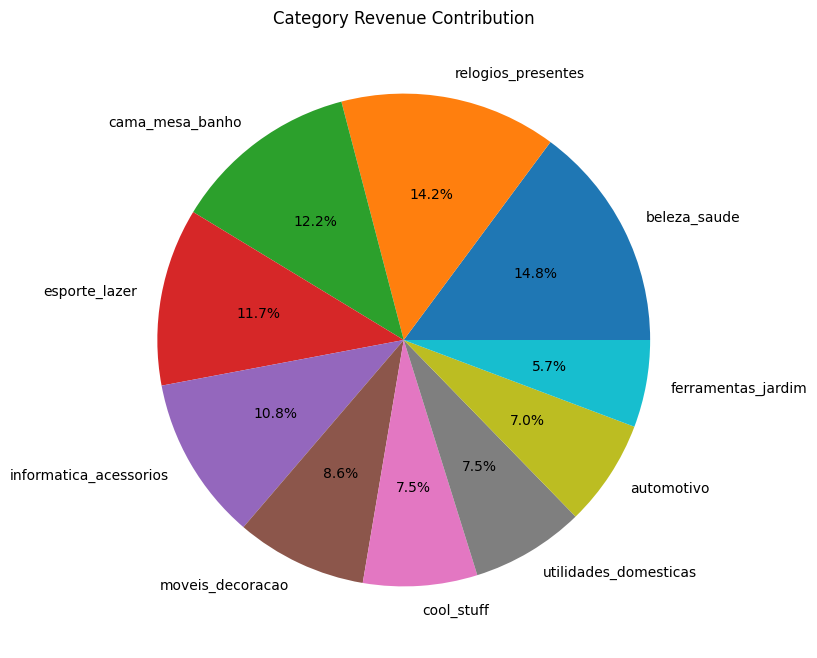

Product Analysis Insights
-------------------------
Total Products: 32951
Top Category: cama_mesa_banho
Best Selling Category: cama_mesa_banho
Highest Revenue Category: beleza_saude


In [7]:
# Highest Freight Products

query = """
SELECT
    product_id,
    ROUND(AVG(freight_value),2) AS avg_freight
FROM order_items
GROUP BY product_id
ORDER BY avg_freight DESC
LIMIT 20;
"""

freight_products = pd.read_sql(query, engine)

freight_products.head()

#Category Contribution %
query = """
SELECT
    p.product_category_name,
    ROUND(
        SUM(oi.price) * 100 /
        (SELECT SUM(price) FROM order_items),
        2
    ) AS contribution_pct
FROM order_items oi
JOIN products p
ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY contribution_pct DESC
LIMIT 10;
"""

contribution = pd.read_sql(query, engine)

contribution

#Pie Chart
plt.figure(figsize=(8,8))

plt.pie(
    contribution['contribution_pct'],
    labels=contribution['product_category_name'],
    autopct='%1.1f%%'
)

plt.title("Category Revenue Contribution")

plt.show()

#Top 20 Best Selling Products
query = """
SELECT
    product_id,
    COUNT(*) AS total_sales
FROM order_items
GROUP BY product_id
ORDER BY total_sales DESC
LIMIT 20;
"""

top_products = pd.read_sql(query, engine)

top_products.head()

#Insights
print("Product Analysis Insights")
print("-------------------------")

print("Total Products:",
      total_products.iloc[0,0])

print("Top Category:",
      top_categories.iloc[0]['product_category_name'])

print("Best Selling Category:",
      best_categories.iloc[0]['product_category_name'])

print("Highest Revenue Category:",
      category_revenue.iloc[0]['product_category_name'])